In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset

raw = pd.read_csv("data/fed_rd_year&gdp.csv")
print(raw.columns)
print(raw.head)

Index(['department', '1976_gdp1790000000000.0', '1977_gdp2028000000000.0',
       '1978_gdp2278000000000.0', '1979_gdp2570000000000.0',
       '1980_gdp2797000000000.0', '1981_gdp3138000000000.0',
       '1982_gdp3314000000000.0', '1983_gdp3541000000000.0',
       '1984_gdp3953000000000.0', '1985_gdp4270000000000.0',
       '1986_gdp4536000000000.0', '1987_gdp4782000000000.0',
       '1988_gdp5155000000000.0', '1989_gdp5570000000000.0',
       '1990_gdp5915000000000.0', '1991_gdp6110000000000.0',
       '1992_gdp6435000000000.0', '1993_gdp6795000000000.0',
       '1994_gdp7198000000000.0', '1995_gdp7583000000000.0',
       '1996_gdp7978000000000.0', '1997_gdp8483000000000.0',
       '1998_gdp8955000000000.0', '1999_gdp9511000000000.0',
       '2000_gdp10148000000000.0', '2001_gdp10565000000000.0',
       '2002_gdp10877000000000.0', '2003_gdp11332000000000.0',
       '2004_gdp12089000000000.0', '2005_gdp12889000000000.0',
       '2006_gdp13685000000000.0', '2007_gdp14323000000000.0',
  

Looking at the cols, it appears that something strange has happened with the names. From https://github.com/rfordatascience/tidytuesday/blob/main/data/2019/2019-02-12/fed_r_d_spending.csv, the numbers are national GDP, so split this into two cols.

In [ ]:
cols = [c for c in raw.columns if '_gdp' in c]
melt = pd.melt(raw, id_vars=['department'], value_vars=cols, var_name='variable', value_name='budget')
print(melt.head)

melt[['year','gdp']] = melt['variable'].str.split('_gdp',expand=True)
melt['gdp'] = melt['gdp'].astype(float)
melt['year'] = melt['year'].astype(int)
df = melt.drop('variable', axis=1)
print(df.head)

<bound method NDFrame.head of     department                  variable        budget
0          DHS   1976_gdp1790000000000.0           NaN
1          DOC   1976_gdp1790000000000.0  8.190000e+08
2          DOD   1976_gdp1790000000000.0  3.569600e+10
3          DOE   1976_gdp1790000000000.0  1.088200e+10
4          DOT   1976_gdp1790000000000.0  1.142000e+09
..         ...                       ...           ...
583        NIH  2017_gdp19177000000000.0  3.305200e+10
584        NSF  2017_gdp19177000000000.0  6.040000e+09
585      Other  2017_gdp19177000000000.0  1.553000e+09
586       USDA  2017_gdp19177000000000.0  2.625000e+09
587         VA  2017_gdp19177000000000.0  1.367000e+09

[588 rows x 3 columns]>
<bound method NDFrame.head of     department        budget  year           gdp
0          DHS           NaN  1976  1.790000e+12
1          DOC  8.190000e+08  1976  1.790000e+12
2          DOD  3.569600e+10  1976  1.790000e+12
3          DOE  1.088200e+10  1976  1.790000e+12
4         

In [ ]:
budget_year = df.pivot_table(
    index="year",
    values="budget",
    aggfunc="sum"
)
print(budget_year)

            budget
year              
1976  8.622700e+10
1977  9.180700e+10
1978  9.486400e+10
1979  9.660100e+10
1980  9.630500e+10
1981  9.830400e+10
1982  9.544800e+10
1983  9.501000e+10
1984  1.053710e+11
1985  1.148180e+11
1986  1.182310e+11
1987  1.253140e+11
1988  1.268000e+11
1989  1.289120e+11
1990  1.291260e+11
1991  1.300080e+11
1992  1.331720e+11
1993  1.320800e+11
1994  1.272780e+11
1995  1.248830e+11
1996  1.239780e+11
1997  1.270180e+11
1998  1.296980e+11
1999  1.368670e+11
2000  1.422990e+11
2001  1.531970e+11
2002  1.703540e+11
2003  1.920100e+11
2004  1.991040e+11
2005  2.000990e+11
2006  1.994290e+11
2007  2.018270e+11
2008  2.008570e+11
2009  2.012750e+11
2010  2.045560e+11
2011  1.942560e+11
2012  1.889440e+11
2013  1.721210e+11
2014  1.753830e+11
2015  1.746080e+11
2016  1.858850e+11
2017  1.636060e+11


Can now perform visualizations with the cleaned df

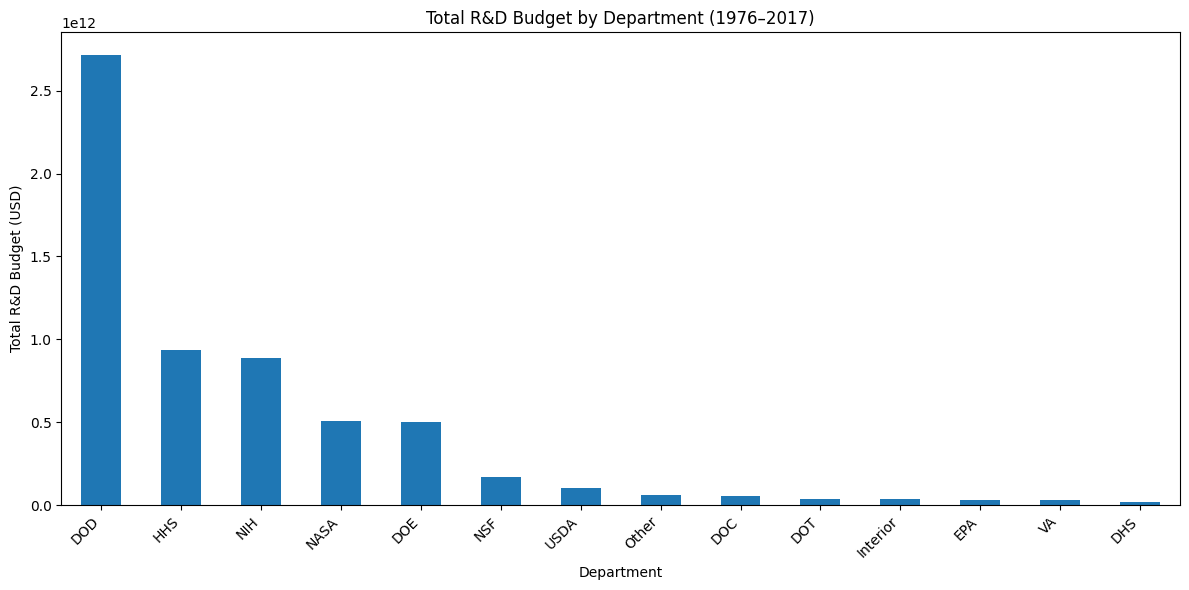

In [ ]:
by_dept = df.groupby("department")["budget"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
by_dept.plot(kind="bar")
plt.title("Total R&D Budget by Department (1976–2017)")
plt.xlabel("Department")
plt.ylabel("Total R&D Budget (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

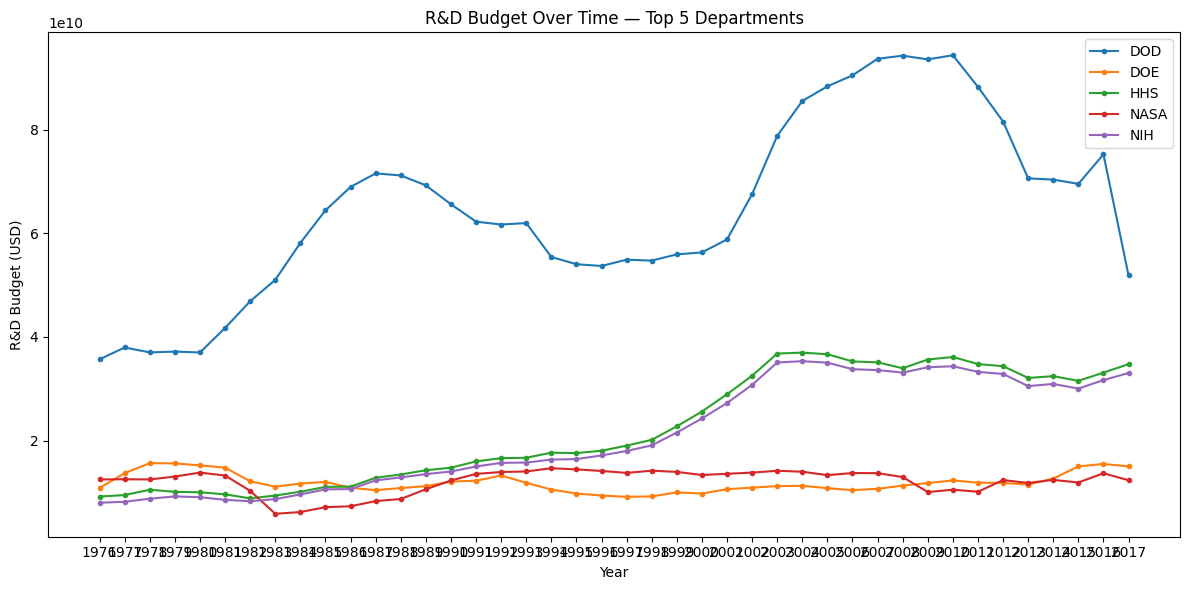

In [ ]:
top5 = by_dept.head(5).index.tolist()
rd_top5 = df[df["department"].isin(top5)]

plt.figure(figsize=(12,6))
for dept, group in rd_top5.groupby("department"):
    plt.plot(group["year"], group["budget"], label=dept, marker="o", markersize=3)

plt.title("R&D Budget Over Time — Top 5 Departments")
plt.xlabel("Year")
plt.ylabel("R&D Budget (USD)")
plt.legend()
plt.tight_layout()
plt.show()